# EDA: `df_artists_final.csv`

This notebook explores the `df_artists_final` dataset. Each row represents one artist. The dataset contains features describing:

- **Chart momentum:** years to first top-20 hit, number of prior charting songs, weeks on chart
- **Genre membership:** one-hot encoded genre flags and a count of genres per artist
- **Social network analysis features:** centrality metrics from a co-charting network
- **Target variable:** `top_20_hitmaker` (1 = hitmaker, 0 = one-hit wonder)


## 2. Dataset Overview

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('df_artists_final.csv')
print("Loaded successfully:", df.shape)

Loaded successfully: (759, 27)


In [4]:
print("Shape:", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)

Shape: (759, 27)

Column names and dtypes:
years_through_first_top_20_hit                  float64
#_of_charting_songs_through_first_top_20_hit    float64
top_20_hit_song_#_wks_on_chart_any_position     float64
artist_genre_Blues                                 bool
artist_genre_Classical                             bool
artist_genre_Country/Americana                     bool
artist_genre_Easy Listening/Vocal                  bool
artist_genre_Electronic/Dance                      bool
artist_genre_Experimental/Avant-Garde              bool
artist_genre_Folk                                  bool
artist_genre_Gospel/Christian/Religious            bool
artist_genre_Hip Hop/Rap                           bool
artist_genre_Jazz                                  bool
artist_genre_Latin                                 bool
artist_genre_Metal                                 bool
artist_genre_Pop                                   bool
artist_genre_Punk/Hardcore                         bool
artis

In [5]:
df.head()

,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,artist_genre_Blues,artist_genre_Classical,artist_genre_Country/Americana,artist_genre_Easy Listening/Vocal,artist_genre_Electronic/Dance,artist_genre_Experimental/Avant-Garde,artist_genre_Folk,artist_genre_Gospel/Christian/Religious,artist_genre_Hip Hop/Rap,artist_genre_Jazz,artist_genre_Latin,artist_genre_Metal,artist_genre_Pop,artist_genre_Punk/Hardcore,artist_genre_R&B/Soul/Funk,artist_genre_Reggae/Caribbean,artist_genre_Rock,artist_genre_World Music,artist_genre_unknown,#_of_genres_artist,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,top_20_hitmaker
0,1.0000,9.0000,27.0000,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,1,5314.3635,0.0101,0.1510,1.0000
1,2.0000,15.0000,41.0000,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,0,1,5233.4360,0.0013,0.0798,1.0000
2,1.0000,2.0000,53.0000,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,0,3,0.0000,0.0000,0.0000,1.0000
3,1.0000,1.0000,37.0000,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,True,False,0,5,0.0000,0.0000,0.0000,1.0000
4,1.0000,6.0000,20.0000,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,0,2,1.0000,0.0000,0.0000,1.0000


In [6]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")
if n_dupes > 0:
    print("\nSample of duplicate rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))

Duplicate rows: 71

Sample of duplicate rows:


,years_through_first_top_20_hit,#_of_charting_songs_through_first_top_20_hit,top_20_hit_song_#_wks_on_chart_any_position,artist_genre_Blues,artist_genre_Classical,artist_genre_Country/Americana,artist_genre_Easy Listening/Vocal,artist_genre_Electronic/Dance,artist_genre_Experimental/Avant-Garde,artist_genre_Folk,artist_genre_Gospel/Christian/Religious,artist_genre_Hip Hop/Rap,artist_genre_Jazz,artist_genre_Latin,artist_genre_Metal,artist_genre_Pop,artist_genre_Punk/Hardcore,artist_genre_R&B/Soul/Funk,artist_genre_Reggae/Caribbean,artist_genre_Rock,artist_genre_World Music,artist_genre_unknown,#_of_genres_artist,harmonic_closeness_centrality_top20_rolling5,betweenness_centrality_top20_rolling5,eigenvector_centrality_top20_rolling5,top_20_hitmaker
41,1.0000,1.0000,1.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.0000,0.0000,0.0000,0.0000
145,1.0000,1.0000,1.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.0000,0.0000,0.0000,0.0000
40,1.0000,1.0000,5.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.0000,0.0000,0.0000,0.0000
264,1.0000,1.0000,5.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.0000,0.0000,0.0000,0.0000
280,1.0000,1.0000,20.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.0000,0.0000,0.0000,0.0000
554,1.0000,1.0000,20.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.0000,0.0000,0.0000,0.0000
664,1.0000,1.0000,20.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,0.0000,0.0000,0.0000,0.0000
755,1.0000,1.0000,21.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,1.0000,0.0000,0.0000,0.0000
756,1.0000,1.0000,21.0000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1,0,1.0000,0.0000,0.0000,0.0000
274,1.0000,1.0000,36.0000,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,0,1,0.0000,0.0000,0.0000,0.0000


## 3. Missing Value Analysis


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

                                             Missing Count  Missing %
top_20_hit_song_#_wks_on_chart_any_position             87    11.4625


Only `top_20_hit_song_#_wks_on_chart_any_position` has missing values. We check whether the missingness is **random** or **structured**.

In [8]:
col = 'top_20_hit_song_#_wks_on_chart_any_position'
df['is_missing'] = df[col].isnull().astype(int)

miss_by_target = df.groupby('top_20_hitmaker')['is_missing'].mean()
print("Missingness rate by target class:")
print(miss_by_target)

df.drop(columns='is_missing', inplace=True)

Missingness rate by target class:
top_20_hitmaker
0.0000   0.1555
1.0000   0.0610
Name: is_missing, dtype: float64


## 4. Target Variable Distribution

Class counts:
top_20_hitmaker
0.0000    431
1.0000    328
Name: count, dtype: int64

Class percentages:
top_20_hitmaker
0.0000   56.7900
1.0000   43.2100
Name: proportion, dtype: float64


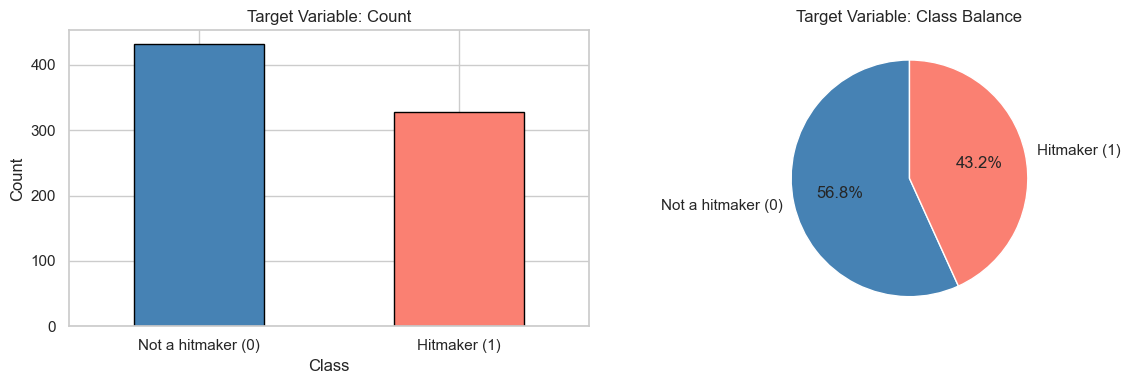

In [9]:
target_counts = df['top_20_hitmaker'].value_counts()
target_pct = df['top_20_hitmaker'].value_counts(normalize=True) * 100

print("Class counts:")
print(target_counts)
print("\nClass percentages:")
print(target_pct.round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

target_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'salmon'], edgecolor='black')
ax1.set_title('Target Variable: Count')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Not a hitmaker (0)', 'Hitmaker (1)'], rotation=0)

ax2.pie(target_counts.values, labels=['Not a hitmaker (0)', 'Hitmaker (1)'],
        autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
ax2.set_title('Target Variable: Class Balance')

plt.tight_layout()
plt.show()

## 5. Chart Momentum Features

The three chart momentum features capture an artist's trajectory leading up to and including their first top-20 hit:

- `years_through_first_top_20_hit` — how many years into their career the artist got their first top-20 hit
- `#_of_charting_songs_through_first_top_20_hit` — number of songs that charted (below top 20) before the first top-20 hit
- `top_20_hit_song_#_wks_on_chart_any_position` — how many weeks the first top-20 hit spent on the charts

We start with summary statistics.

In [10]:
numeric_cols = [
    'years_through_first_top_20_hit',
    '#_of_charting_songs_through_first_top_20_hit',
    'top_20_hit_song_#_wks_on_chart_any_position'
]

df[numeric_cols].describe().T.assign(
    skewness=df[numeric_cols].skew(),
    kurtosis=df[numeric_cols].kurt()
)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
years_through_first_top_20_hit,759.0000,2.1436,4.0776,1.0000,1.0000,1.0000,2.0000,61.0000,8.9562,107.2168
#_of_charting_songs_through_first_top_20_hit,759.0000,2.8208,3.7019,1.0000,1.0000,2.0000,3.0000,44.0000,5.1690,38.9116
top_20_hit_song_#_wks_on_chart_any_position,672.0000,27.8557,12.0512,1.0000,20.0000,26.0000,34.0000,87.0000,0.6689,1.3484


We now plot the distributions to visually inspect their shape.

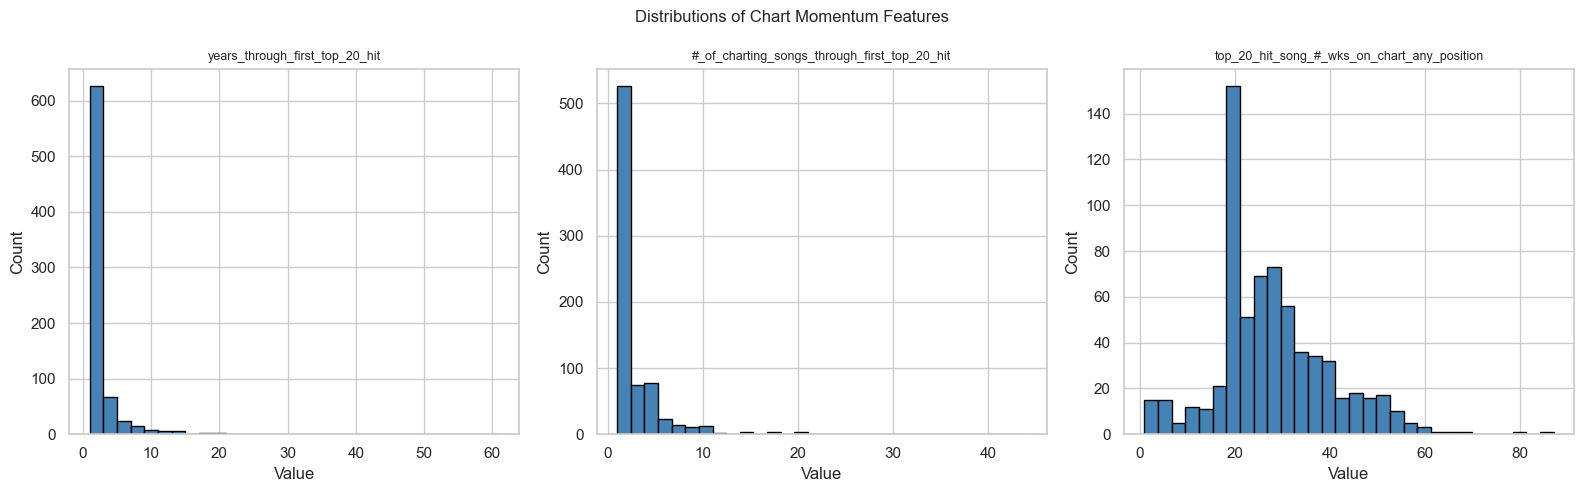

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=30, edgecolor='black', color='steelblue')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Distributions of Chart Momentum Features', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
print("Outlier counts (IQR rule):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {n_outliers} outliers")

Outlier counts (IQR rule):
  years_through_first_top_20_hit: 89 outliers
  #_of_charting_songs_through_first_top_20_hit: 57 outliers
  top_20_hit_song_#_wks_on_chart_any_position: 13 outliers


## 6. Genre Features — Frequency Analysis

Genre membership is one-hot encoded: there is a separate True/False column for each of the 20 genres. An artist can belong to multiple genres simultaneously. We count how many artists fall into each genre, and examine how many genres a typical artist spans.

In [13]:
genre_cols = [c for c in df.columns if c.startswith('artist_genre_')]

genre_counts = df[genre_cols].sum().sort_values(ascending=False)
genre_pct = (genre_counts / len(df) * 100).round(2)

genre_summary = pd.DataFrame({'Count': genre_counts, 'Percent': genre_pct})
print(genre_summary)

                                         Count  Percent
artist_genre_Pop                           357  47.0400
artist_genre_Hip Hop/Rap                   290  38.2100
artist_genre_Rock                          198  26.0900
artist_genre_R&B/Soul/Funk                 172  22.6600
artist_genre_unknown                       146  19.2400
artist_genre_Electronic/Dance              112  14.7600
artist_genre_Country/Americana              55   7.2500
artist_genre_Folk                           54   7.1100
artist_genre_Metal                          48   6.3200
artist_genre_Punk/Hardcore                  48   6.3200
artist_genre_Jazz                           35   4.6100
artist_genre_Latin                          26   3.4300
artist_genre_Reggae/Caribbean               18   2.3700
artist_genre_Easy Listening/Vocal           17   2.2400
artist_genre_Classical                      15   1.9800
artist_genre_World Music                    10   1.3200
artist_genre_Gospel/Christian/Religious      8  

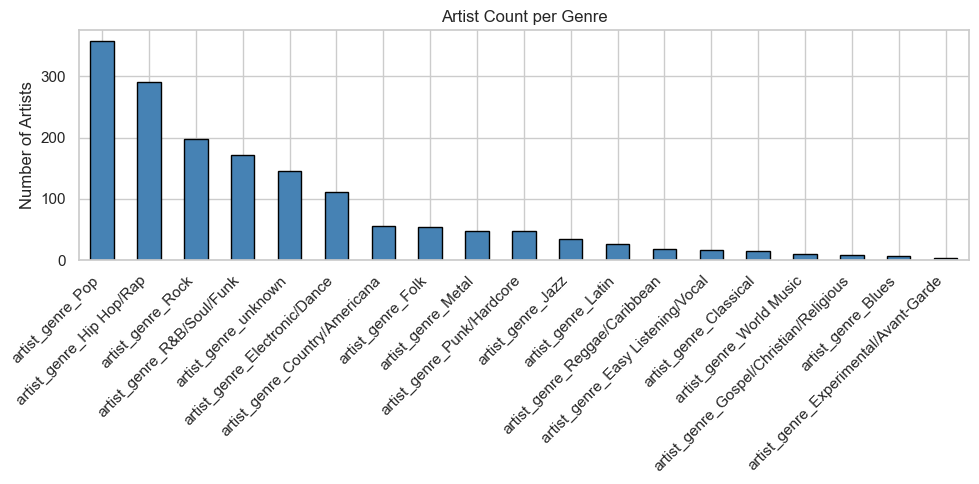

In [14]:
genre_counts.plot(kind='bar', edgecolor='black', color='steelblue')
plt.title('Artist Count per Genre')
plt.ylabel('Number of Artists')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

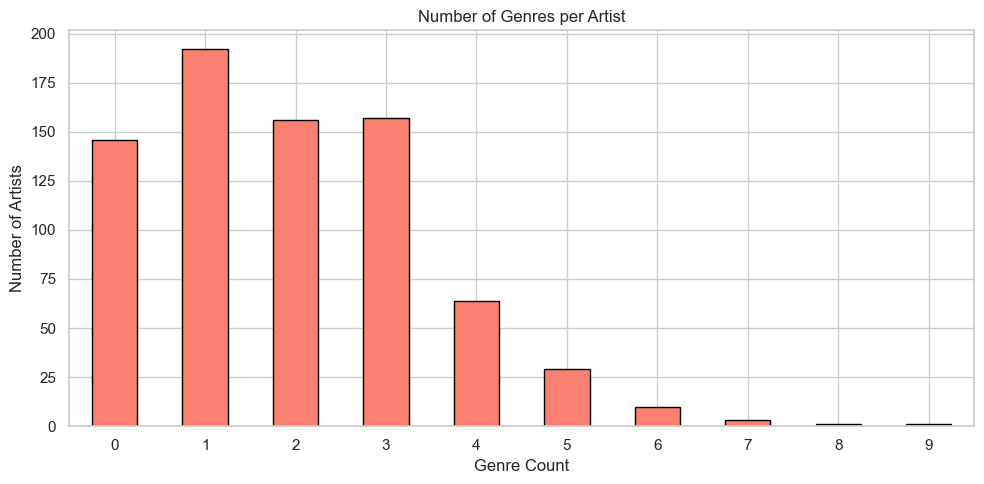

In [15]:
df['#_of_genres_artist'].value_counts().sort_index().plot(
    kind='bar', edgecolor='black', color='salmon'
)
plt.title('Number of Genres per Artist')
plt.xlabel('Genre Count')
plt.ylabel('Number of Artists')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
print("artist_genre_unknown value counts:")
print(df['artist_genre_unknown'].value_counts().sort_index())

artist_genre_unknown value counts:
artist_genre_unknown
0    613
1    146
Name: count, dtype: int64


## 7. Network Centrality Features

These three features measure how connected an artist was in the co-charting network at the time of their first hit.


In [17]:
centrality_cols = [
    'harmonic_closeness_centrality_top20_rolling5',
    'betweenness_centrality_top20_rolling5',
    'eigenvector_centrality_top20_rolling5'
]

df[centrality_cols].describe().T.assign(
    skewness=df[centrality_cols].skew(),
    kurtosis=df[centrality_cols].kurt()
)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
harmonic_closeness_centrality_top20_rolling5,759.0000,2362.9579,1848.6004,0.0000,0.0000,2610.3784,3984.2437,5802.3325,-0.0833,-1.3829
betweenness_centrality_top20_rolling5,759.0000,0.0010,0.0023,0.0000,0.0000,0.0000,0.0005,0.0197,3.6500,16.4480
eigenvector_centrality_top20_rolling5,759.0000,0.0104,0.0250,0.0000,0.0000,0.0004,0.0068,0.1780,3.6362,14.6490


A notable feature of these columns is the presence of zero values. We count how many artists have a value of exactly zero for each centrality measure.

In [18]:
print("Zero value counts per centrality feature:")
for col in centrality_cols:
    n_zero = (df[col] == 0).sum()
    print(f"  {col}: {n_zero} zeros ({n_zero/len(df)*100:.1f}%)")

Zero value counts per centrality feature:
  harmonic_closeness_centrality_top20_rolling5: 206 zeros (27.1%)
  betweenness_centrality_top20_rolling5: 311 zeros (41.0%)
  eigenvector_centrality_top20_rolling5: 206 zeros (27.1%)


We plot the distributions of the non-zero values to examine their shape.

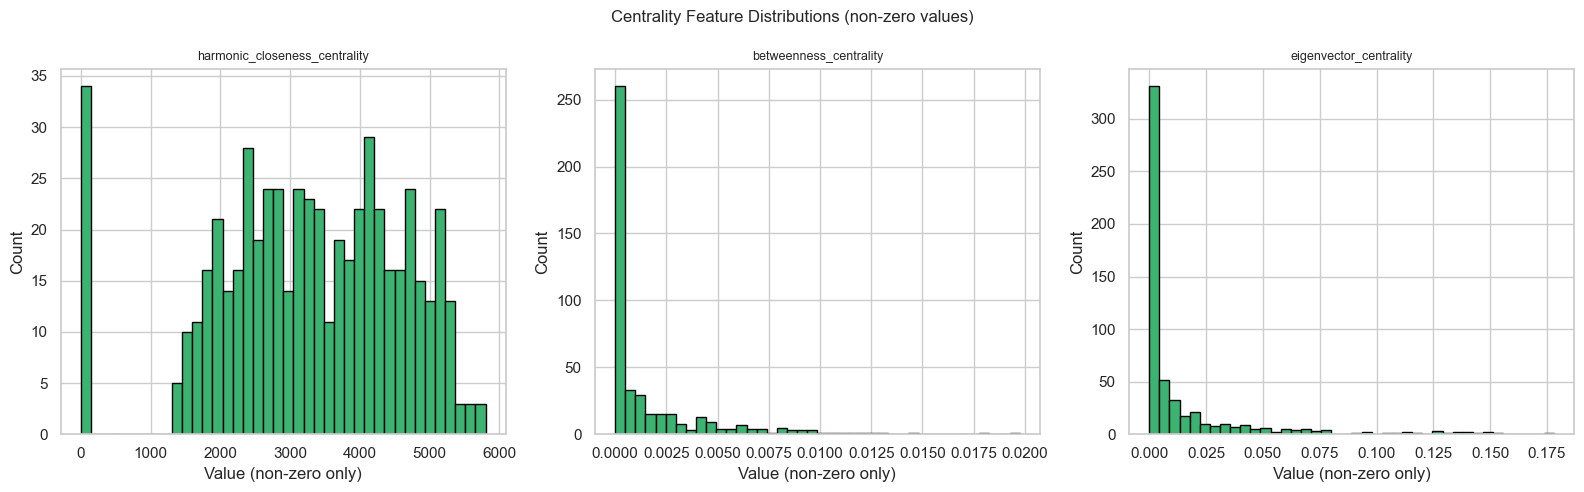

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, centrality_cols):
    data = df[df[col] > 0][col]
    ax.hist(data, bins=40, edgecolor='black', color='mediumseagreen')
    ax.set_title(col.replace('_top20_rolling5', ''), fontsize=9)
    ax.set_xlabel('Value (non-zero only)')
    ax.set_ylabel('Count')

plt.suptitle('Centrality Feature Distributions (non-zero values)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Features vs Target

We now ask whether the numeric, centrality, and genre features differ between hitmakers and one-hit wonders. We use boxplots for a visual comparison and the Mann-Whitney U test to assess statistical significance. Mann-Whitney is a non-parametric test — it works on ranks rather than raw values, making it appropriate for the skewed distributions we observed above.

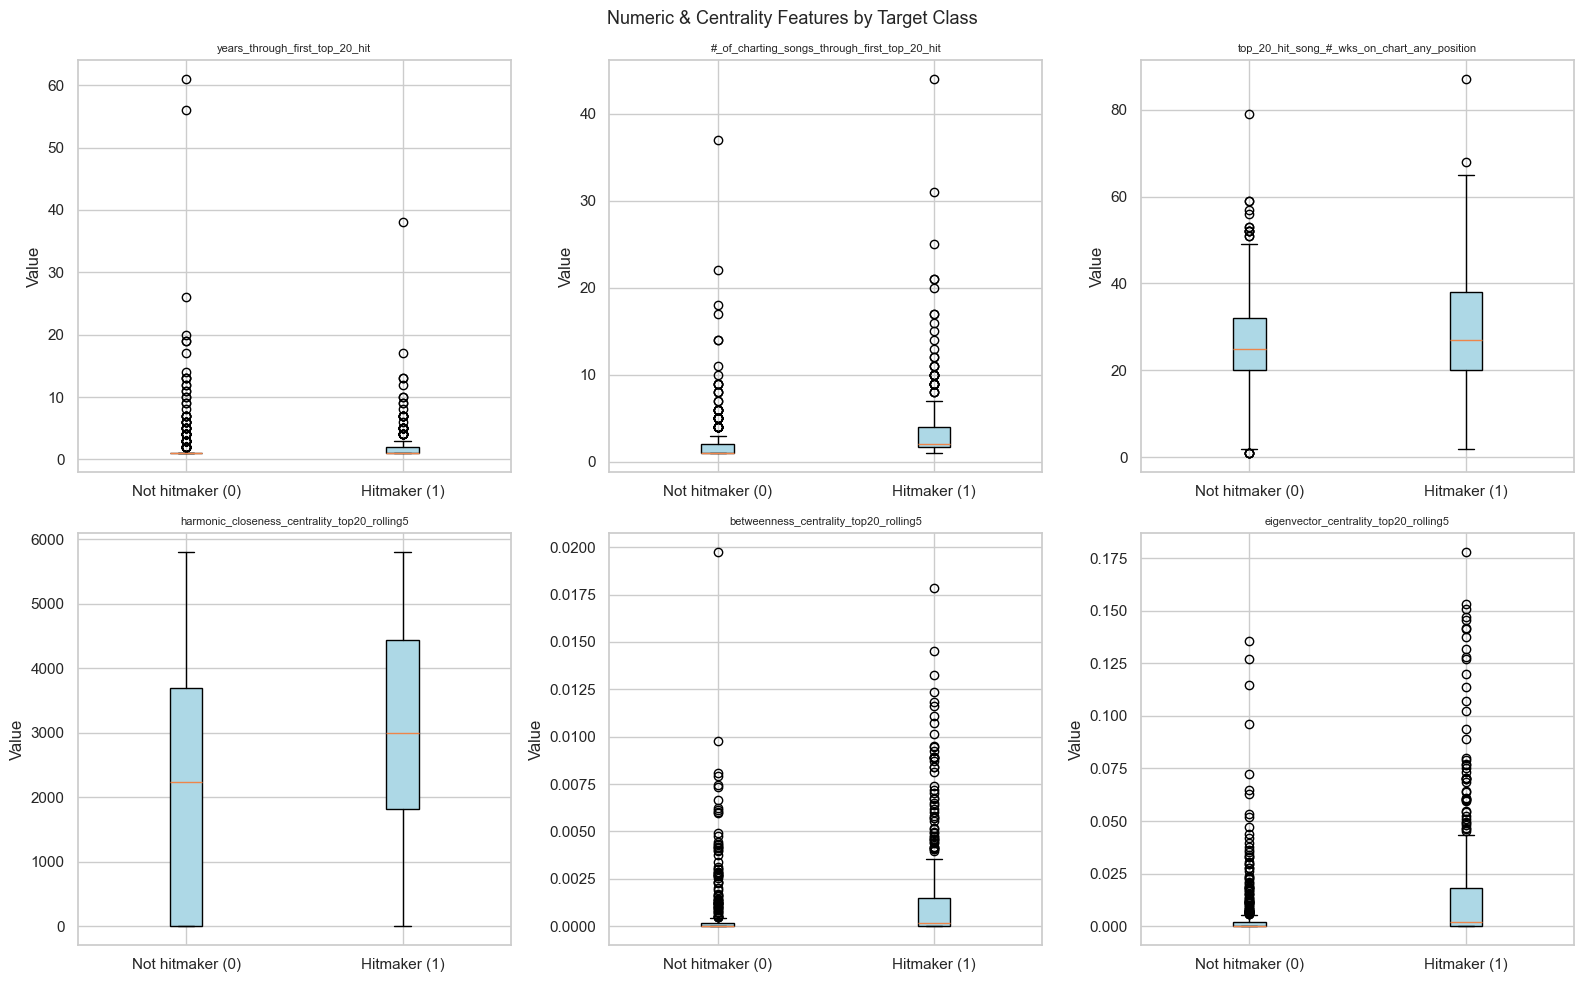

In [20]:
all_numeric = numeric_cols + centrality_cols

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, all_numeric):
    groups = [df[df['top_20_hitmaker'] == cls][col].dropna() for cls in [0, 1]]
    ax.boxplot(groups, tick_labels=['Not hitmaker (0)', 'Hitmaker (1)'], patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col, fontsize=8)
    ax.set_ylabel('Value')

plt.suptitle('Numeric & Centrality Features by Target Class', fontsize=13)
plt.tight_layout()
plt.show()

We complement the boxplots with overlapping histograms to better visualize where the two class distributions overlap.

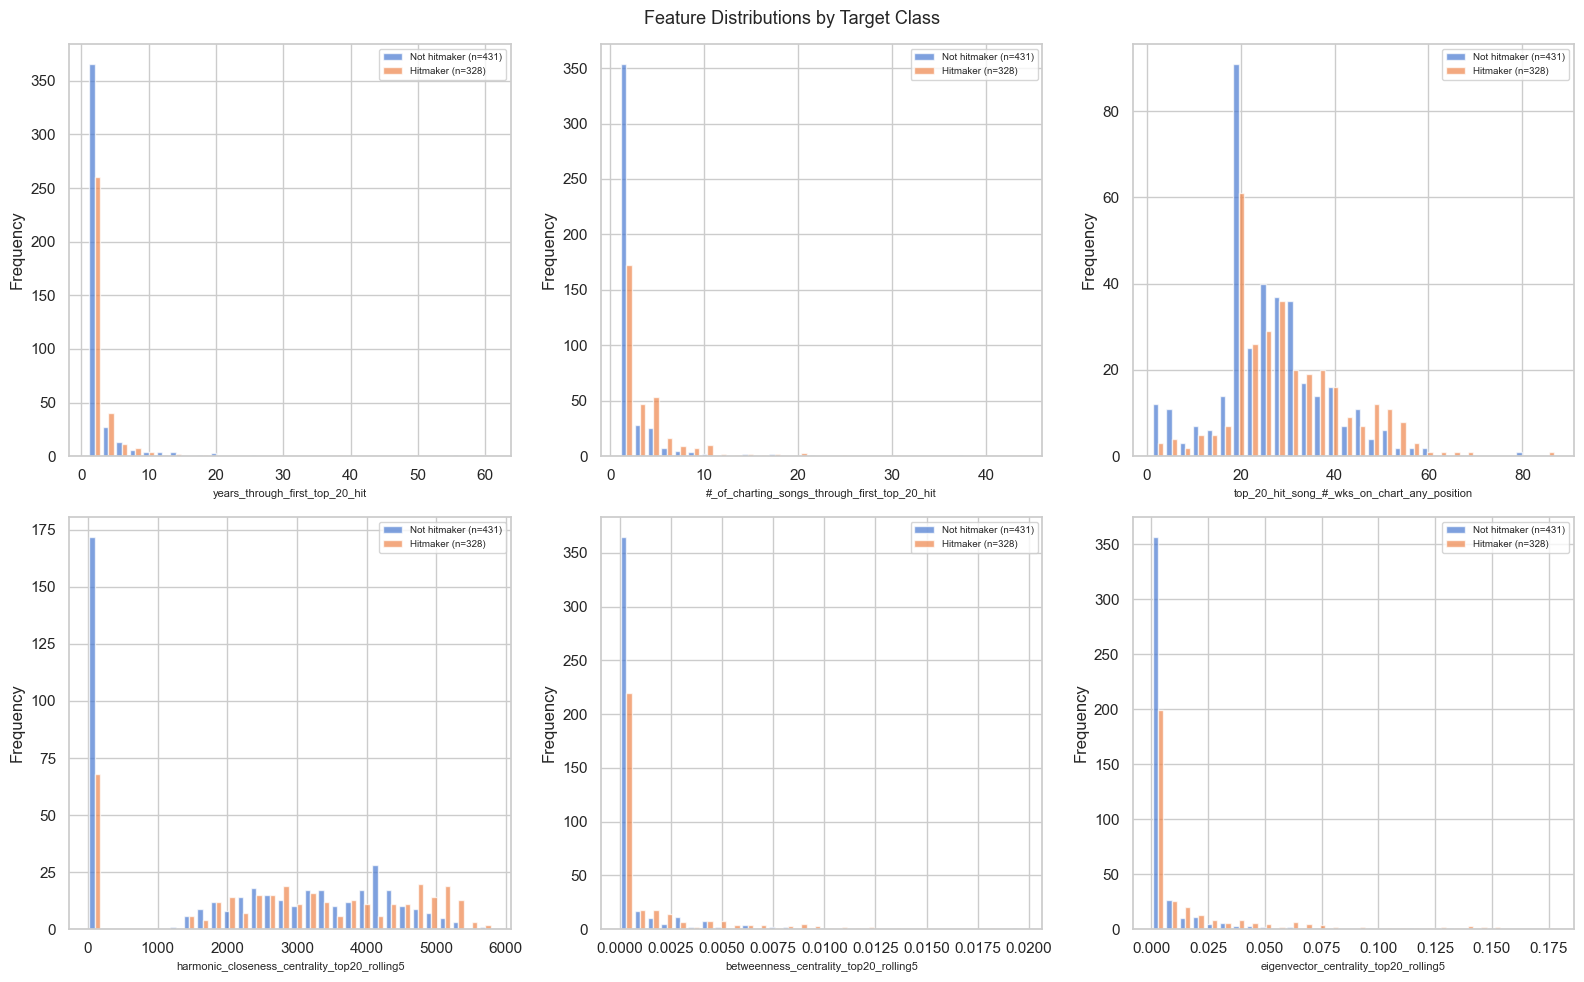

In [21]:
n_0 = (df['top_20_hitmaker'] == 0).sum()
n_1 = (df['top_20_hitmaker'] == 1).sum()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, all_numeric):
    d0 = df[df['top_20_hitmaker'] == 0][col].dropna()
    d1 = df[df['top_20_hitmaker'] == 1][col].dropna()
    ax.hist([d0, d1], bins=30, alpha=0.7,
            label=[f'Not hitmaker (n={n_0})', f'Hitmaker (n={n_1})'])
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Target Class', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
print(f"{'Feature':<55} {'U-stat':>10} {'p-value':>12}")
print("-" * 80)
for col in all_numeric:
    g0 = df[df['top_20_hitmaker'] == 0][col].dropna()
    g1 = df[df['top_20_hitmaker'] == 1][col].dropna()
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
    print(f"{col:<55} {u_stat:>10.1f} {p_val:>12.4f}  {sig}")

Feature                                                     U-stat      p-value
--------------------------------------------------------------------------------
years_through_first_top_20_hit                             62776.0       0.0006  ***
#_of_charting_songs_through_first_top_20_hit               41298.5       0.0000  ***
top_20_hit_song_#_wks_on_chart_any_position                46635.5       0.0002  ***
harmonic_closeness_centrality_top20_rolling5               52679.5       0.0000  ***
betweenness_centrality_top20_rolling5                      47815.0       0.0000  ***
eigenvector_centrality_top20_rolling5                      47859.0       0.0000  ***


Genre prevalence between the two classes.

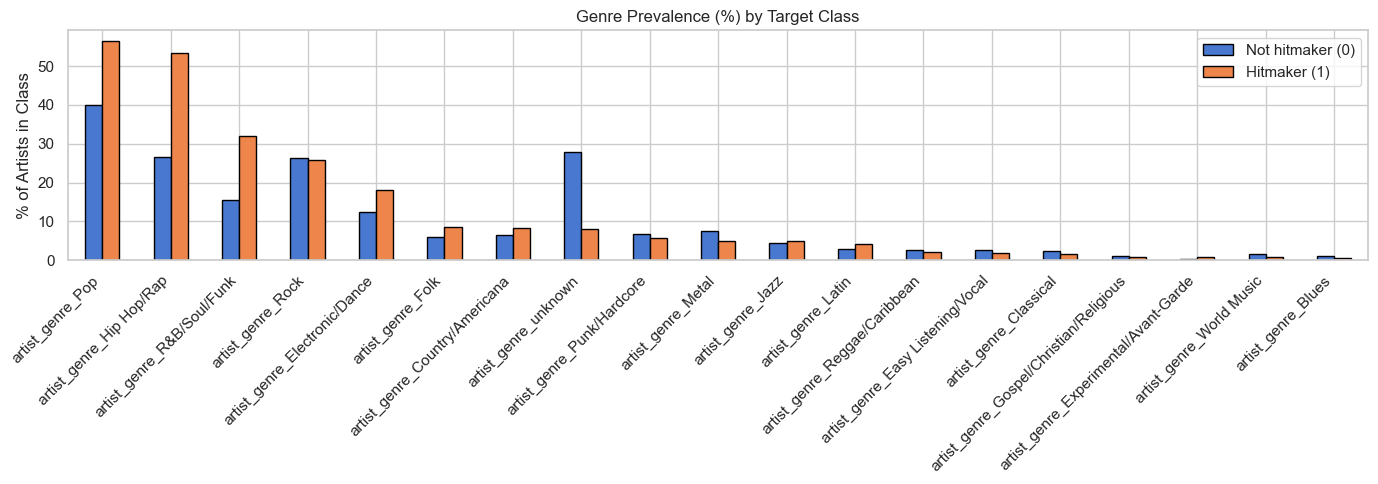

In [23]:
genre_by_target = df.groupby('top_20_hitmaker')[genre_cols].mean() * 100
genre_by_target.T.sort_values(by=1, ascending=False).plot(
    kind='bar', figsize=(14, 5), edgecolor='black'
)
plt.title('Genre Prevalence (%) by Target Class')
plt.ylabel('% of Artists in Class')
plt.xticks(rotation=45, ha='right')
plt.legend(['Not hitmaker (0)', 'Hitmaker (1)'])
plt.tight_layout()
plt.show()

The genre bar chart shows Pop and Hip Hop are more prevalent among hitmakers.

## 9. Correlation Analysis

We compute the Spearman rank correlation matrix across all numeric, centrality, and genre-count features, including the target.

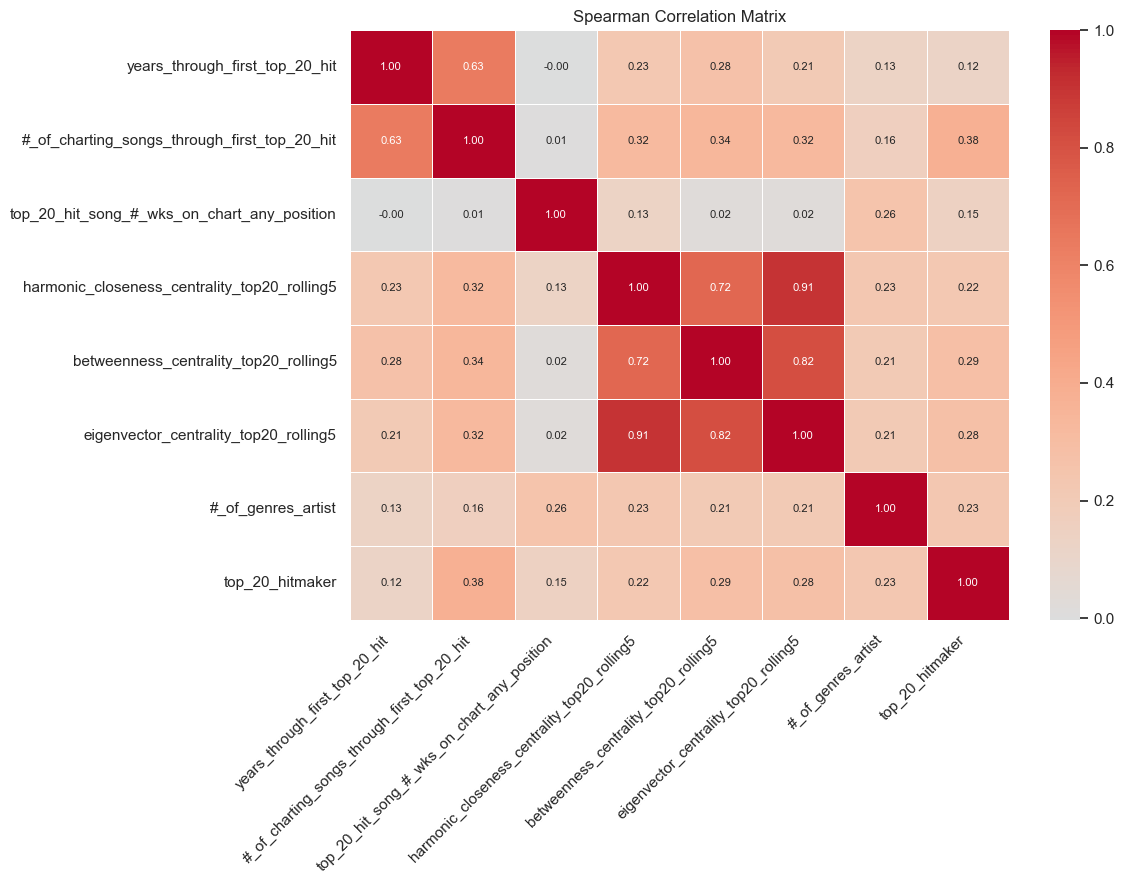

In [24]:
corr_cols = numeric_cols + centrality_cols + ['#_of_genres_artist', 'top_20_hitmaker']
spearman_corr = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(12, 9))
sns.heatmap(
    spearman_corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title('Spearman Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. EDA Summary

**Dataset structure:** 759 artists, 26 features, covering chart momentum, genre, social network analysis, and a binary target (`top_20_hitmaker`).

**Duplicate rows:** 71 exact duplicate rows were found.

**Missing values:** Only `top_20_hit_song_#_wks_on_chart_any_position` has missing data (~11.5%). Missingness is higher among one-hit wonders (15.6%) than hitmakers (6.1%), suggesting it is not random.

**Class balance:** The dataset is mildly imbalanced — 56.8% one-hit wonders vs. 43.2% hitmakers. ROC-AUC is an appropriate evaluation metric given this split.

**Chart momentum features:** All three are right-skewed with notable outliers. `#_of_charting_songs_through_first_top_20_hit` in particular has a long tail.

**Genre features:** Pop (47%) and Hip Hop/Rap (38%) are by far the most common genres in the dataset. About 19% of artists have unknown genre. Most artists span 1–2 genres.

**Network features:** A substantial share of artists have zero values across all three centrality measures.

**Bivariate analysis:** All numeric and centrality features show statistically significant differences between hitmakers and one-hit wonders (Mann-Whitney U, p < 0.001). Pop and Hip Hop genres are more prevalent among hitmakers.

**Correlations:** The three centrality features are moderately correlated with each other. `#_of_charting_songs_through_first_top_20_hit` shows the strongest correlation with the target among the chart momentum features.